In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv("../.env", override=True)

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql(
    "SELECT * FROM ml_rent_market",
    engine
)

print(df.shape)
df.head()

(300, 8)


,guName,yearMonth,contractCount,moveIn,moveOut,netMove,baseRate,avgLivingPop
0,강남구,2024-01,2464,13140,8937,4203,3.5,814365.906419
1,강남구,2024-02,1985,14454,10088,4366,3.5,812009.586478
2,강남구,2024-03,1976,7752,7059,693,3.5,826818.317374
3,강남구,2024-04,1651,6948,6624,324,3.5,824744.923619
4,강남구,2024-05,2539,6824,5592,1232,3.5,816933.047707


In [2]:
print(df.isnull().sum())

guName           0
yearMonth        0
contractCount    0
moveIn           0
moveOut          0
netMove          0
baseRate         0
avgLivingPop     0
dtype: int64


In [3]:
df["yearMonth"] = pd.to_datetime(df["yearMonth"])

df["year"] = df["yearMonth"].dt.year
df["month"] = df["yearMonth"].dt.month

print(df[["yearMonth", "year", "month"]].head())

   yearMonth  year  month
0 2024-01-01  2024      1
1 2024-02-01  2024      2
2 2024-03-01  2024      3
3 2024-04-01  2024      4
4 2024-05-01  2024      5


In [4]:
df = df.sort_values(["guName", "yearMonth"])

df["nextContractCount"] = (
    df.groupby("guName")["contractCount"].shift(-1)
)

print(df[[
    "guName",
    "yearMonth",
    "contractCount",
    "nextContractCount"
]].head(15))

   guName  yearMonth  contractCount  nextContractCount
0     강남구 2024-01-01           2464             1985.0
1     강남구 2024-02-01           1985             1976.0
2     강남구 2024-03-01           1976             1651.0
3     강남구 2024-04-01           1651             2539.0
4     강남구 2024-05-01           2539             2073.0
5     강남구 2024-06-01           2073             1648.0
6     강남구 2024-07-01           1648             1613.0
7     강남구 2024-08-01           1613             1341.0
8     강남구 2024-09-01           1341             1744.0
9     강남구 2024-10-01           1744             1696.0
10    강남구 2024-11-01           1696             2098.0
11    강남구 2024-12-01           2098                NaN
12    강동구 2024-01-01           1520             1240.0
13    강동구 2024-02-01           1240             1605.0
14    강동구 2024-03-01           1605             1223.0


In [5]:
model_df = df.dropna(subset=["nextContractCount"]).copy()

print(model_df.shape)

(275, 11)


In [6]:
features = [
    "contractCount",
    "moveIn",
    "moveOut",
    "netMove",
    "baseRate",
    "avgLivingPop",
    "month"
]

X = model_df[features]
y = model_df["nextContractCount"]

print(X.shape)
print(y.shape)

(275, 7)
(275,)


In [7]:
train = model_df[model_df["month"] <= 9].copy()
test = model_df[model_df["month"] >= 10].copy()

X_train = train[features]
y_train = train["nextContractCount"]

X_test = test[features]
y_test = test["nextContractCount"]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (225, 7)
Test: (50, 7)


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2:", r2_score(y_test, pred))

MAE: 117.81459999999998
RMSE: 178.26312659941763
R2: 0.8698242412402806


In [10]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
5,avgLivingPop,0.512489
0,contractCount,0.397531
1,moveIn,0.026778
2,moveOut,0.026421
3,netMove,0.019935
6,month,0.016845
4,baseRate,0.000000


In [11]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
5,avgLivingPop,0.512489
0,contractCount,0.397531
1,moveIn,0.026778
2,moveOut,0.026421
3,netMove,0.019935
6,month,0.016845
4,baseRate,0.000000


In [12]:
result = test[["guName", "yearMonth"]].copy()
result["actual"] = y_test.values
result["predicted"] = pred
result["error"] = result["actual"] - result["predicted"]

result.head(10)

,guName,yearMonth,actual,predicted,error
9,강남구,2024-10-01,1696.0,1777.455,-81.455
10,강남구,2024-11-01,2098.0,1601.050,496.950
21,강동구,2024-10-01,1373.0,1299.610,73.390
22,강동구,2024-11-01,1876.0,1363.790,512.210
33,강북구,2024-10-01,204.0,224.240,-20.240
34,강북구,2024-11-01,272.0,219.020,52.980
45,강서구,2024-10-01,1375.0,1286.460,88.540
46,강서구,2024-11-01,1059.0,1281.905,-222.905
57,관악구,2024-10-01,530.0,1019.145,-489.145
58,관악구,2024-11-01,606.0,631.815,-25.815


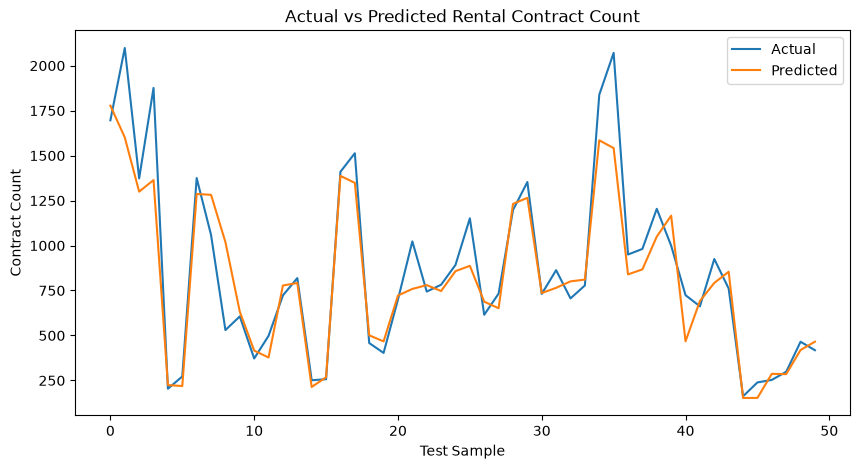

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(result)),
    result["actual"],
    label="Actual"
)

plt.plot(
    range(len(result)),
    result["predicted"],
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Contract Count")
plt.title("Actual vs Predicted Rental Contract Count")
plt.legend()
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R2:", r2_score(y_test, lr_pred))

MAE: 115.61481434230693
RMSE: 172.4718283356225
R2: 0.8781449833548578


In [16]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [
        mean_absolute_error(y_test, pred),
        mean_absolute_error(y_test, lr_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, pred) ** 0.5,
        mean_squared_error(y_test, lr_pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, pred),
        r2_score(y_test, lr_pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,117.814600,178.263127,0.869824
1,Linear Regression,115.614814,172.471828,0.878145


In [17]:
baseline_pred = X_test["contractCount"]

print("Baseline")
print("MAE:", mean_absolute_error(y_test, baseline_pred))
print("RMSE:", mean_squared_error(y_test, baseline_pred) ** 0.5)
print("R2:", r2_score(y_test, baseline_pred))

Baseline
MAE: 110.56
RMSE: 154.81072314281076
R2: 0.901823135584503


In [18]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, baseline_pred) ** 0.5,
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, lr_pred),
        r2_score(y_test, pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline,110.560000,154.810723,0.901823
1,Linear Regression,115.614814,172.471828,0.878145
2,Random Forest,117.814600,178.263127,0.869824


In [19]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

coef_df

,feature,coefficient
6,month,1.498012e+00
0,contractCount,6.371528e-01
3,netMove,-3.389747e-02
2,moveOut,2.304237e-02
1,moveIn,-1.085509e-02
5,avgLivingPop,9.231811e-04
4,baseRate,-2.220446e-16


In [20]:
lr_features = [
    "contractCount",
    "moveIn",
    "moveOut",
    "baseRate",
    "avgLivingPop",
    "month"
]

X_train_lr = train[lr_features]
X_test_lr = test[lr_features]

lr_model2 = LinearRegression()
lr_model2.fit(X_train_lr, y_train)

lr_pred2 = lr_model2.predict(X_test_lr)

print("MAE:", mean_absolute_error(y_test, lr_pred2))
print("RMSE:", mean_squared_error(y_test, lr_pred2) ** 0.5)
print("R2:", r2_score(y_test, lr_pred2))

MAE: 115.61481434230669
RMSE: 172.47182833562326
R2: 0.8781449833548567


In [21]:
coef_df2 = pd.DataFrame({
    "feature": lr_features,
    "coefficient": lr_model2.coef_
}).sort_values("coefficient", key=abs, ascending=False)

coef_df2

,feature,coefficient
5,month,1.498012e+00
0,contractCount,6.371528e-01
2,moveOut,5.693984e-02
1,moveIn,-4.475256e-02
4,avgLivingPop,9.231811e-04
3,baseRate,2.399123e-15


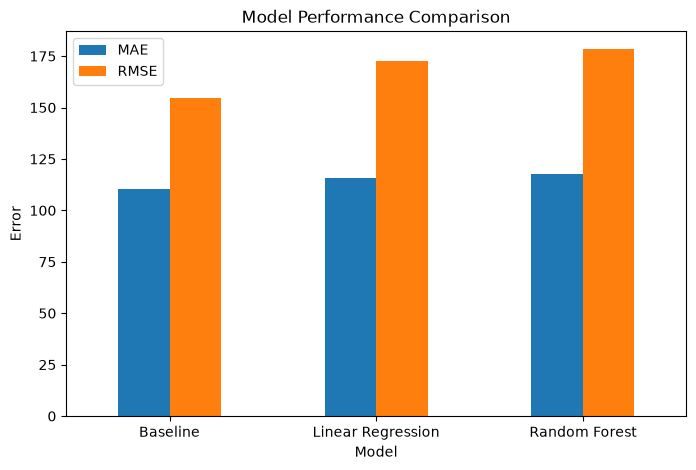

In [22]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()

In [4]:
import os
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv("../.env", override=True)

engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [5]:
df = pd.read_sql("SELECT * FROM ml_rent_market", engine)

print(df.shape)
print(df["yearMonth"].min(), df["yearMonth"].max())

(900, 8)
2023-01 2025-12


In [6]:
df["yearMonth"] = pd.to_datetime(df["yearMonth"])

df = df.sort_values(["guName", "yearMonth"])

df["year"] = df["yearMonth"].dt.year
df["month"] = df["yearMonth"].dt.month

df["nextContractCount"] = (
    df.groupby("guName")["contractCount"].shift(-1)
)

model_df = df.dropna(subset=["nextContractCount"]).copy()

print(model_df.shape)
print(model_df["yearMonth"].min(), model_df["yearMonth"].max())

(875, 11)
2023-01-01 00:00:00 2025-11-01 00:00:00


In [7]:
features = [
    "contractCount",
    "moveIn",
    "moveOut",
    "netMove",
    "baseRate",
    "avgLivingPop",
    "month"
]

train = model_df[model_df["year"] <= 2024].copy()
test = model_df[model_df["year"] == 2025].copy()

X_train = train[features]
y_train = train["nextContractCount"]

X_test = test[features]
y_test = test["nextContractCount"]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (600, 7)
Test: (275, 7)


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("R2:", r2_score(y_test, pred))

MAE: 106.70609090909092
RMSE: 179.60515663760376
R2: 0.8892138855251535


In [9]:
baseline_pred = X_test["contractCount"]

print("Baseline")
print("MAE:", mean_absolute_error(y_test, baseline_pred))
print("RMSE:", mean_squared_error(y_test, baseline_pred) ** 0.5)
print("R2:", r2_score(y_test, baseline_pred))

Baseline
MAE: 115.73818181818181
RMSE: 196.6670467382049
R2: 0.8671654893098972


In [10]:
from sklearn.linear_model import LinearRegression

lr_features = [
    "contractCount",
    "moveIn",
    "moveOut",
    "baseRate",
    "avgLivingPop",
    "month"
]

lr_model = LinearRegression()

lr_model.fit(
    train[lr_features],
    y_train
)

lr_pred = lr_model.predict(test[lr_features])

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
MAE: 113.97722414565592
RMSE: 192.561490962638
R2: 0.872653618917076


In [11]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, baseline_pred) ** 0.5,
        mean_squared_error(y_test, lr_pred) ** 0.5,
        mean_squared_error(y_test, pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, lr_pred),
        r2_score(y_test, pred)
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline,115.738182,196.667047,0.867165
1,Linear Regression,113.977224,192.561491,0.872654
2,Random Forest,106.706091,179.605157,0.889214


In [12]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
0,contractCount,0.677166
5,avgLivingPop,0.255037
1,moveIn,0.018481
2,moveOut,0.017999
3,netMove,0.016212
6,month,0.013610
4,baseRate,0.001495


In [13]:
result = test[["guName", "yearMonth"]].copy()

result["actual"] = y_test.values
result["predicted"] = pred
result["error"] = result["actual"] - result["predicted"]

print(result.head(10))

   guName  yearMonth  actual  predicted    error
24    강남구 2025-01-01  2344.0   2264.695   79.305
25    강남구 2025-02-01  2120.0   2457.440 -337.440
26    강남구 2025-03-01  1988.0   1992.135   -4.135
27    강남구 2025-04-01  2236.0   2227.300    8.700
28    강남구 2025-05-01  2028.0   2532.125 -504.125
29    강남구 2025-06-01  1969.0   2049.150  -80.150
30    강남구 2025-07-01  1978.0   2001.225  -23.225
31    강남구 2025-08-01  2000.0   1812.685  187.315
32    강남구 2025-09-01  2071.0   2135.955  -64.955
33    강남구 2025-10-01  2732.0   2204.720  527.280


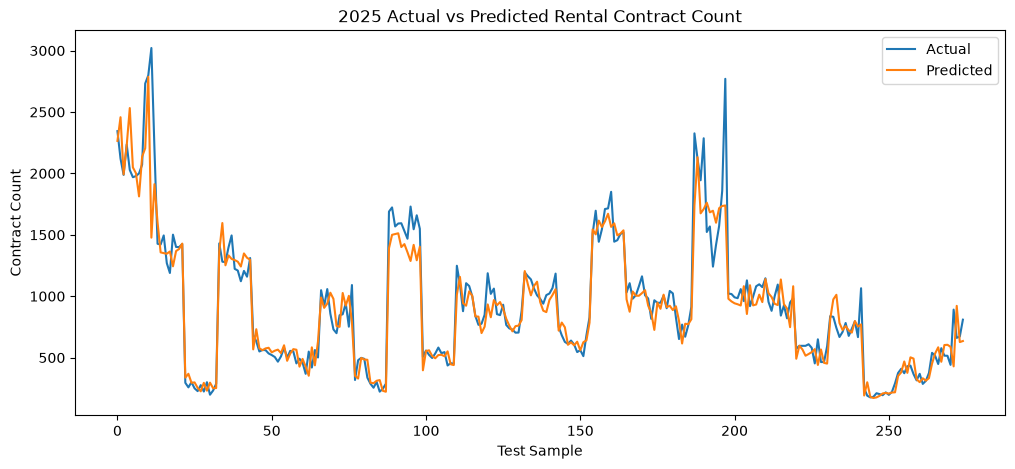

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(range(len(result)), result["actual"], label="Actual")
plt.plot(range(len(result)), result["predicted"], label="Predicted")

plt.xlabel("Test Sample")
plt.ylabel("Contract Count")
plt.title("2025 Actual vs Predicted Rental Contract Count")
plt.legend()
plt.show()

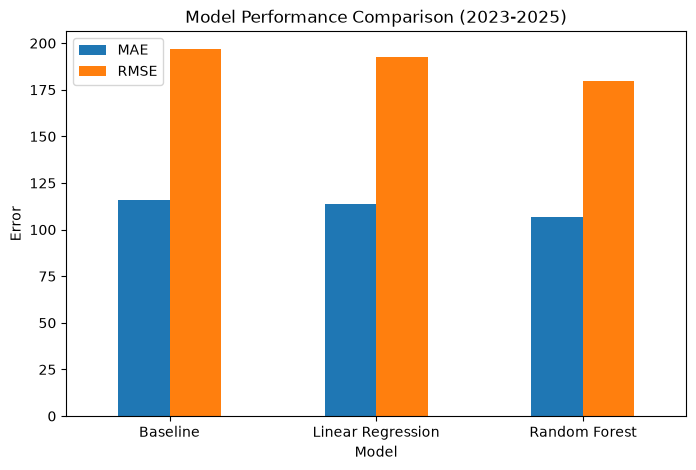

In [15]:
comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Model Performance Comparison (2023-2025)")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.show()